# Data Analysis of Liver Steatosis

Rin Hwang 

DATA 101 Introduction to Data Science

May 13, 2026

## Introduction

In this project, I explored a Liver Steatosis dataset that contains 443 patients that underwent bariatric surgery at the Cleveland Clinic between 2005 and 2009 and had a liver biopsy. It includes 22 clinical variables of body measurements, metabolic markers, blood chemistry, and final biopsy findings. 

The research question I am investigating is: "To what extent do age, BMI, and diabetes status predict the presence of liver steatosis as confirmed by biopsy?" 

There is empirical evidence that there exists an association between higher BMI and diagnosis of diabetes mellitus (high blood sugar) with fibrosis severity and development of various types of liver diseases (Kaya et al., 2025). This question can potentially help with improving early intervention and know more about identifying patients are at a higher risk of developing liver fat related diseases such as liver steatosis. 

The source of this data comes The Teaching of Statistics in the Health Sciences. This data is uniquely appropriate for this research because it includes both these simple health markers and confirmed biopsy results, and thus it can be effective at testing if there can be accurate prediction of liver disease without needing invasive surgery. 

Link to dataset: https://causeweb.org/tshs/liver-steatosis/

The variables I used to effectively examine my question are: 

- "Age": A quantitative variable for the patient's age in years.

- "BMI": A quantitative variable calculating body mass by height and weight.

- "DM": A categorical variable identifying whether or not the patient has diabetes mellitus, which is a chronic disease regarding high blood sugar levels.

- "LS_Biopsy": A categorical variable that identifies whether or not the patient's biopsy results were confirmed liver steatosis (fatty liver).

## Data Analysis and Methodology

To start my data analysis, I first performed some preliminary data cleaning using data selection and filtering. I selected the columns/variables I needed (['Age', 'BMI', 'DM', 'LS_Biopsy']), then I filtered out missing values. I also filtered out "inconclusive" cases for "LS_Biopsy" which were initially encoded to 0.5. I filtered these out because I wished to properly represent definite liver steatosis or not, given that there were only 8 instances which is less than 1% of the population data and did not have much effect on statistics. There were also some outliers I could see from an initial boxplot visualization, thus I thought it was best to filter those out by using IQR.

In the exploratory data analysis, I wanted to first see the BMI distribution of the biopsy results through a boxplot after outliers were removed. In the boxplot, it reveals that the median BMI and interquartile ranges remain nearly identical for both negative and positive results. By capping the y-axis at approximately 70, the plot highlights that even after removing extreme values, the data for both groups heavily overlaps, showing why BMI alone is potentially a weak predictor for liver steatosis. The pairplot shows the joint and individual distributions of Age and BMI, color-coded by the liver steatosis biopsy result. This visualization reveals a significant overlap between the two classes in both scatter plots and density curves, indicating that neither variable provides a clear linear separation for predicting steatosis on its own. The third plot is a heatmap that displays correlation coefficients between predictors and the biopsy target, emphasizing multi-collinearity between features. It reveals that diabetes (DM) has the strongest positive association with liver steatosis at 0.12. In contrast, Age (0.043) and BMI (0.045) show a very small correlation with the target.

To proceed with the logistic regression, I first subsetted the data to include Age, BMI, and Diabetes (DM), the dataset was split into an 80% training set and a 20% testing set to ensure proper validation. Feature scaling was performed using StandardScaler to ensure all markers were on a comparable scale before using it. I then trained a logistic regression model to establish a baseline performance, generating class probabilities to determine the model's ability to distinguish between positive and negative biopsy outcomes. An AUC-ROC of 0.544 indicates that the original logistic regression model performs only slightly better than random guessing (0.50). This low value confirms that individual predictors of Age, BMI and Diabetes, do not provide enough clear separation to accurately distinguish between patients with and without liver steatosis.

The Principal Component Analysis results indicate that the first two principal components effectively condense the majority of the information from the original feature set, capturing a cumulative variance of 77.09%. Individually, the first component accounts for 46.91% of the dataset's variance, while the second adds 30.19%, leaving only 22.91% in the third component. The model simplifies the complex relationships between clinical predictors, such as the overlaps and correlations visualized in the heatmap and pairplot, into a more distinct metabolic signal. This reduction justifies using only the first two components for subsequent modeling, as they retain the most significant patterns needed to distinguish liver steatosis outcomes.

The results demonstrate that despite filtering outliers, Age, BMI, and Diabetes status remain insufficient for reliably classifying liver steatosis in this bariatric population. While the PCA captured a significant 77.09% of the data's cumulative variance within the first two components, it led to a slight decrease in predictive performance, with the AUC-ROC dropping from 0.544 in the original model to 0.527 after transformation. These scores, being only marginally better than a random guess, confirm the observations in the heatmap and pairplot that the features are too heavily overlapped to provide a clear linear or metabolic signal. Ultimately, the transition to PCA showed that while dataset could be simplified and explain most of its variance, the resulting components did not have the distinction power necessary to improve diagnostic accuracy for this specific patient population.

## Conclusion and Future Directions

The primary objective of this analysis was to determine if Age, BMI, and Diabetes (DM) could effectively predict liver steatosis in a bariatric patient population. After removing extreme outliers using the IQR method, the analysis yielded two primary results: a baseline Logistic Regression model with an AUC-ROC of 0.544 and a PCA-transformed model with an AUC-ROC of 0.527. These findings indicate that even after focusing on the core metabolic signals that capture 77.09% of the data's variance, the clinical features provided very little differentiating power. Connecting back to the research question, the results suggest that these three variables alone are not sufficient diagnostic markers for distinguishing liver steatosis outcomes in this specific population.

The scree plot visualizes the Explained Variance Ratio, helping to justify the dimensionality reduction of three clinical variables into two principal components. The blue bars represent the individual variance, showing that the first component captures approximately 46.9% of the data's patterns, while the second adds another 30.2%. The red step-line tracks the cumulative variance, confirming that by using just the first two components, we retain a substantial 77.1% of the total variance while effectively filtering out the remaining 22.9%. 

These results are meaningful because they highlight a "diagnostic gap" when relying on standard physical and demographic metrics for high-risk groups. The heavy overlap seen in the pairplot and the weak correlations in the heatmap suggest that for patients already in a high BMI category, small changes in weight or age don't clearly signal a higher risk of liver steatosis. This implies that within the bariatric population, the actual drivers of liver fat accumulation likely involve other complex metabolic shifts rather than just body mass. The fact that PCA failed to boost the model's performance indicates that the issue wasn't just from extreme outliers, but a deeper lack of linear separation between the two patient groups. 

I stated earlier that there is medical literature widely recognizing a strong association between higher BMI, diabetes mellitus (high blood sugar), and increased fibrosis severity and various liver diseases. In this research, diabetes was indeed the strongest individual predictor (0.12), aligning with its role in metabolic stress of the liver. However, the boxplot does show that the median BMI and the interquartile ranges are nearly identical for both the negative and positive steatosis groups. This extensive overlap indicates that there is no specific BMI threshold that separates negative and positive results. Therefore, while the plot shows that high BMI is a known risk factor, it also effectively demonstrates how the variable loses its predictive power in a population where almost everyone already has a high BMI.

For future directions, I would like to utilize feature engineering by creating new interaction variables such as BMI multiplied by Age, to test if the risk of steatosis scales more aggressively when both metabolic stressors are elevated simultaneously. Additionally, I would also like to try dividing the population into specific groups, such as Class II versus Class III obesity, to potentially determine if BMI actually becomes a better predictor within certain weight brackets instead of treating every bariatric patient the same way. Similarly, looking at how long or how severely a patient has had diabetes might reveal a much clearer metabolic signal for steatosis than the simple "yes/no" label we used in the correlation matrix heatmap.

## References

Kaya, E., Vilar-Gomez, E., Vuppalanchi, R., & Yilmaz, Y. (2025). Body mass index and diabetes predict severity of liver fibrosis across the spectrum of steatotic liver disease. Annals of hepatology, 30(1), 101907. https://doi.org/10.1016/j.aohep.2025.101907 

Nowacki, A. S. (2025). Liver Steatosis Dataset. TSHS Resources Portal. https://causeweb.org/tshs/liver-steatosis/ 

## Code

### Importing libraries and dataset

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.decomposition import PCA

In [102]:
df = pd.read_csv("C:/Users/hwang/OneDrive/Documents/MC stuff/Spring 2026/DATA 101 Introduction to Data Science/Projects/Final Project/Liver_Steatosis_TSHS.csv")

### Getting variable info

In [103]:
df.head()

,Age,Sex,Height,Weight,BMI,Obesity_Duration,DM,MET_Syndrome,HTN,HPL,...,HDL,LDL,VLDL,AST,ALT,NAS,Fibrosis,LS_US,LS_Biopsy,Other_Etiology
0,61.2,2,162.6,127.189,48.130000,35.0,0.0,1.0,1.0,1.0,...,50.0,124.0,28.0,22.0,14.0,3.0,0,1.0,1.0,0.0
1,40.4,2,165.1,137.757,50.540000,23.0,1.0,1.0,1.0,1.0,...,49.0,143.0,21.0,50.0,78.0,6.0,0,0.0,1.0,0.0
2,38.5,1,193.0,217.137,58.270000,11.0,1.0,1.0,1.0,0.0,...,51.0,78.0,17.0,30.0,35.0,3.0,1,1.0,1.0,0.0
3,65.0,1,161.0,131.000,50.538174,20.0,1.0,1.0,1.0,0.0,...,55.0,113.0,NaN,21.0,26.0,1.0,0,1.0,1.0,0.0
4,56.3,2,165.1,124.000,45.490000,22.0,0.0,1.0,1.0,0.0,...,46.0,57.0,31.0,12.0,15.0,1.0,0,0.0,1.0,0.0


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 443 entries, 0 to 442
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               443 non-null    float64
 1   Sex               443 non-null    int64  
 2   Height            443 non-null    float64
 3   Weight            443 non-null    float64
 4   BMI               443 non-null    float64
 5   Obesity_Duration  436 non-null    float64
 6   DM                441 non-null    float64
 7   MET_Syndrome      441 non-null    float64
 8   HTN               440 non-null    float64
 9   HPL               441 non-null    float64
 10  TG                411 non-null    float64
 11  CHOL              411 non-null    float64
 12  HDL               411 non-null    float64
 13  LDL               395 non-null    float64
 14  VLDL              393 non-null    float64
 15  AST               437 non-null    float64
 16  ALT               437 non-null    float64
 1

### Preliminary Data Cleaning

The results are already encoded as: 

"DM:" 0 is no, 1 is yes

"LS_Biopsy": 0 is no, 1 is yes

In [105]:
# Selection
df_select = df.loc[:, ['Age', 'BMI', 'DM', 'LS_Biopsy']].copy()

# Filter out missing values
df_clean = df_select.dropna()

# Filter out inconclusive cases 
inconclusive_count = df_select[df_select['LS_Biopsy'] == 0.5].shape[0]
df_clean = df_select[df_select['LS_Biopsy'].isin([0, 1])].copy()

# Filter out outliers using IQR
features = ['Age', 'BMI']

Q1 = df_clean[features].quantile(0.25)
Q3 = df_clean[features].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_clean[~((df_clean[features] < lower_bound) | (df_clean[features] > upper_bound)).any(axis=1)]

print(f"New dataset size after IQR: {df_clean.shape[0]}")

print(df_clean[['Age', 'BMI']].describe())

New dataset size after IQR: 422
              Age         BMI
count  422.000000  422.000000
mean    46.119905   46.264377
std     11.743851    7.343261
min     17.300000   27.290000
25%     37.125000   41.313713
50%     46.050000   45.300000
75%     55.275000   50.855000
max     72.000000   66.863324


### Exploratory Data Analysis (EDA) 

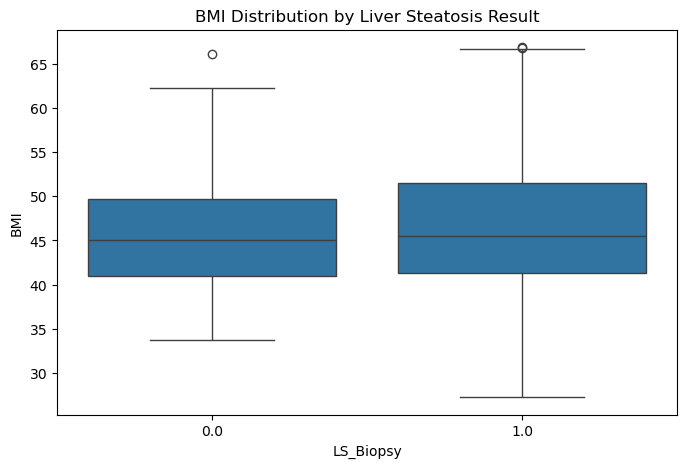

In [106]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='LS_Biopsy', y='BMI', data=df_clean)
plt.title('BMI Distribution by Liver Steatosis Result')
plt.show()

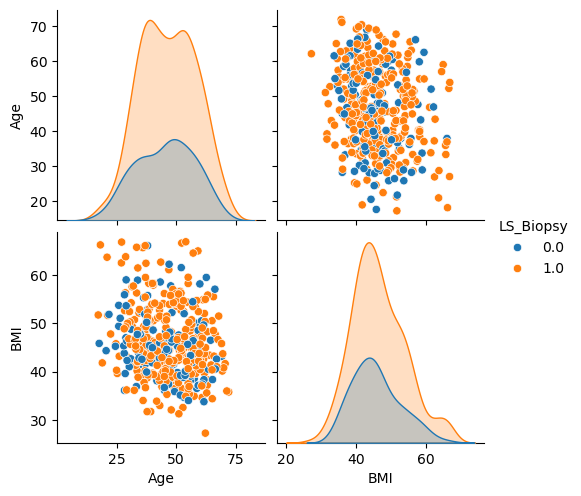

In [107]:
sns.pairplot(df_clean, hue='LS_Biopsy', vars=['Age', 'BMI'])
plt.show()

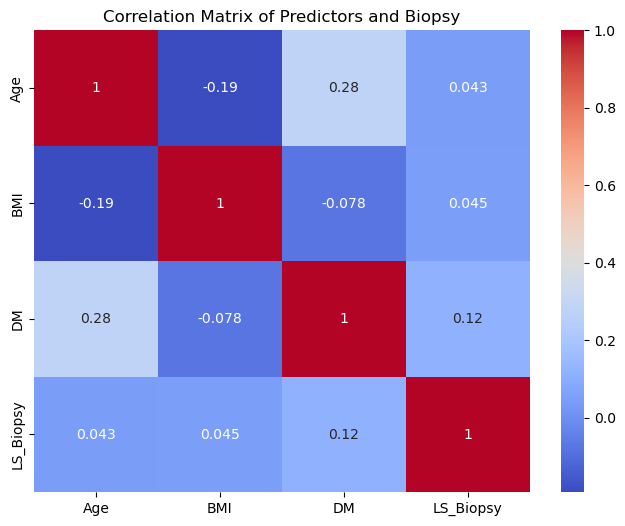

In [108]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Predictors and Biopsy')
plt.show()

### Logistic Regression

In [110]:
# Scaling
X = df_clean[['Age', 'BMI', 'DM']]
y = df_clean['LS_Biopsy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1
log_reg_orig = LogisticRegression()
log_reg_orig.fit(X_train_scaled, y_train)

y_pred_orig = log_reg_orig.predict(X_test_scaled)
y_prob_orig = log_reg_orig.predict_proba(X_test_scaled)[:, 1]

auc_score = roc_auc_score(y_test, y_prob_orig)
print(f"Original Model AUC-ROC: {auc_score:.3f}")

Original Model AUC-ROC: 0.544


### Principal Component Analysis (PCA)

In [111]:
pca = PCA()
X_train_pca_all = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)[:, :2]

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print(f"Explained Variance: {explained_variance}\nCumulative Variance: {cumulative_variance}")

# Model 2
log_reg_pca = LogisticRegression(solver='liblinear').fit(X_train_pca_all[:, :2], y_train)
y_prob_pca = log_reg_pca.predict_proba(X_test_pca)[:, 1]

pca_df = pd.DataFrame(X_train_pca_all[:, :2], columns=['PC1', 'PC2'])
pca_df['Target'] = y_train.values

Explained Variance: [0.46905299 0.30189436 0.22905265]
Cumulative Variance: [0.46905299 0.77094735 1.        ]


### Results

In [112]:
print(f"\nOriginal AUC-ROC: {roc_auc_score(y_test, y_prob_orig):.3f}")
print(f"PCA AUC-ROC: {roc_auc_score(y_test, y_prob_pca):.3f}")
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")


Original AUC-ROC: 0.544
PCA AUC-ROC: 0.527
Explained Variance Ratio: [0.46905299 0.30189436 0.22905265]


### Visualization

Creating a scree plot to plot the justification

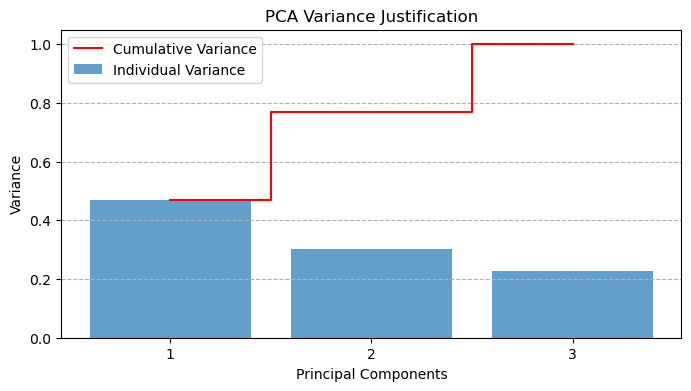

In [100]:
plt.figure(figsize=(8, 4))

plt.bar(range(1, 4), explained_variance, alpha=0.7, label='Individual Variance')
plt.step(range(1, 4), cumulative_variance, where='mid', label='Cumulative Variance', color='red')

plt.xlabel('Principal Components')
plt.ylabel('Variance')
plt.title('PCA Variance Justification')
plt.xticks([1, 2, 3]) # Explicitly mark PC1, PC2, and PC3
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()